# **<span style="font-family: Arial">Music Recommendation Algorithm - Model creation, Hyperparameter search, and Model evaluation  </span>**

**Author:** Ozor Moya

**Date:** 05/24/2026

**Goal:** To find natural groupings of songs using KMeans clustering on the preprocessed data from the transformation notebook. This involves determining the optimal number of clusters, profiling each cluster to understand what types of songs it contains, and applying the final model to the test dataset to assign each recommendation song to its closest cluster, laying the foundation for the recommendation logic.

---
### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

---
### 2. Load cleaned data

In [2]:
# Load the cleaned csv file
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/train_cleaned.csv')

In [3]:
# Check how many rows and columns
df.shape

(28362, 14)

In [4]:
# Checking the first 5 lines of the dataset
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,0.496553,1.082219,-1.397833,-0.772258,0.778972,0.572968,1.497797,-0.197341,-0.133055,0.749815,0.698580,0.650449,-0.573701,1.067722
1,2.274500,0.261477,1.869530,1.146213,-0.942924,-1.226515,0.061855,-0.577677,-0.151830,-0.279899,0.619603,-0.275371,0.519277,0.659182
2,-0.926250,3.513248,-0.077179,-0.978525,-1.115643,-0.477947,2.653549,0.242785,0.947926,1.951869,-0.626659,0.173853,-0.421447,1.068882
3,0.561223,2.100011,-0.361075,0.867737,0.435179,0.282664,-1.308286,-1.289722,2.032981,0.221688,-1.868561,1.864661,-0.881086,0.870874
4,1.823603,1.827116,-0.010701,1.717206,-0.919258,-0.908090,-0.046692,-1.061545,2.403241,-0.146650,-1.091730,2.259257,-0.746859,0.351056


---
### 3. Find the optimal number of clusters

I decided to use two complementary methods to find the right k objectively:
- **Elbow Method** — measures how compact the clusters are (lower inertia = tighter clusters)
- **Silhouette Score** — measures how well-separated the clusters are from each other (higher = better)

Using both together gives a more reliable answer than either alone.

---
#### 3.1 Elbow Method

k= 2 | inertia=425,512.5
k= 3 | inertia=393,755.0
k= 4 | inertia=364,121.3
k= 5 | inertia=335,269.5
k= 6 | inertia=313,423.9
k= 7 | inertia=293,369.0
k= 8 | inertia=274,978.3
k= 9 | inertia=266,170.9
k=10 | inertia=252,091.1
k=11 | inertia=243,790.2
k=12 | inertia=231,381.4


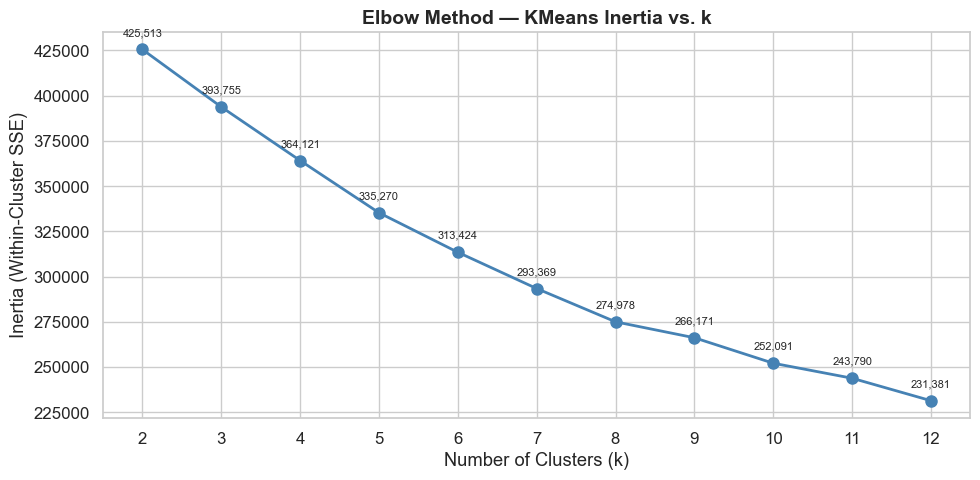

In [5]:
inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df)
    inertias.append(km.inertia_)
    print(f"k={k:2d} | inertia={km.inertia_:,.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue', markersize=8)
ax.set_title('Elbow Method — KMeans Inertia vs. k', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_xticks(list(k_range))

for k, v in zip(k_range, inertias):
    ax.annotate(f'{v:,.0f}', (k, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig17_elbow_plot.png', bbox_inches='tight')
plt.show()

- The inertia curve shows a continuous, gradual decrease from k=2 to k=12 without a sharp, obvious elbow. This tells the dataset does not have a small number of perfectly separated clusters, instead, song themes blend into each other progressively, and each additional cluster keeps carving out a meaningful sub-group. This is expected given the EDA finding that `feelings` and `world/life` are diffuse, overlapping themes.

---
#### 3.2 Silhouette Score

k= 2 | silhouette=0.1376
k= 3 | silhouette=0.1137
k= 4 | silhouette=0.1315
k= 5 | silhouette=0.1569
k= 6 | silhouette=0.1767
k= 7 | silhouette=0.1918
k= 8 | silhouette=0.2069
k= 9 | silhouette=0.2007
k=10 | silhouette=0.2113
k=11 | silhouette=0.2060
k=12 | silhouette=0.2154


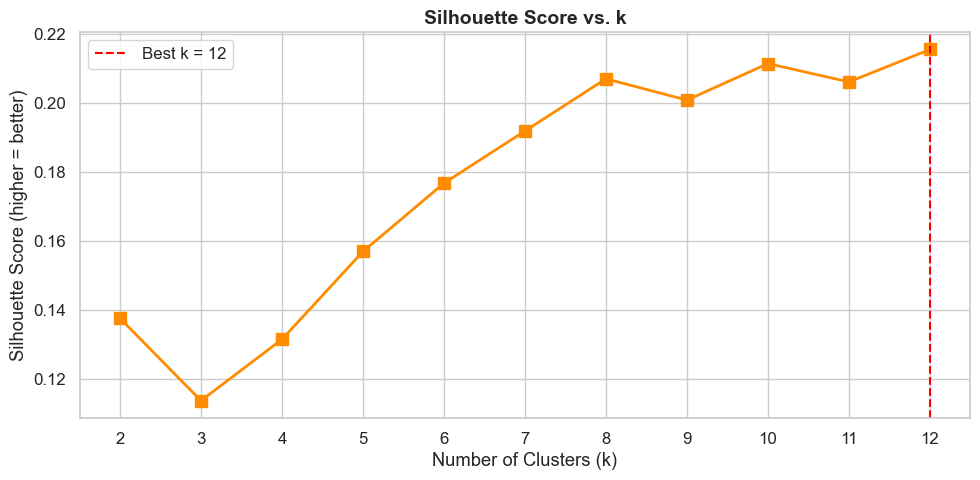


Best k by silhouette: 12 (score = 0.2154)


In [6]:
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df)
    score = silhouette_score(df, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    print(f"k={k:2d} | silhouette={score:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='darkorange', markersize=8)
ax.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score (higher = better)')
ax.set_xticks(list(k_range))

best_k_sil = list(k_range)[np.argmax(silhouette_scores)]
ax.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best k = {best_k_sil}')
ax.legend()

plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig18_silhouette_plot.png', bbox_inches='tight')
plt.show()

print(f"\nBest k by silhouette: {best_k_sil} (score = {max(silhouette_scores):.4f})")

- The silhouette score rises steadily from k=2 (0.138) through k=12 (0.215), with no clear peak within the tested range, it keeps improving as k increases. While scores in the 0.20–0.22 range are moderate rather than strong, this is typical for music/text-derived data where themes genuinely overlap and songs don't form hard, well-separated boundaries. The steady improvement confirms that finer-grained groupings are consistently more coherent than coarser ones for this dataset. k=12 is selected as it achieves the best silhouette score within my tested range while remaining interpretable.

---
### 4. Choose optimal K

In [7]:
inertia_drops = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
elbow_k = list(k_range)[np.argmax(inertia_drops) + 1]

print(f"Elbow method suggests k = {elbow_k}")
print(f"Silhouette score suggests k = {best_k_sil}")

BEST_K = best_k_sil
print(f"\n>>> Final chosen k = {BEST_K} <<<")

Elbow method suggests k = 3
Silhouette score suggests k = 12

>>> Final chosen k = 12 <<<


---
### 5. Fit the Final KMeans Model

In [8]:
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(df)

train_orig = pd.read_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/music_rec/train.csv')
train_orig = train_orig.iloc[df.index].reset_index(drop=True)
X_reset = df.reset_index(drop=True)

train_orig['cluster'] = cluster_labels

print("Cluster distribution:")
print(train_orig['cluster'].value_counts().sort_index())
print("\nTotal rows:", len(train_orig))

Cluster distribution:
cluster
0     4859
1     4563
2     1601
3     4422
4      792
5     1087
6     3978
7     1694
8     2060
9     1240
10    1019
11    1047
Name: count, dtype: int64

Total rows: 28362


---
### 6. Cluster Profiling

In [9]:
num_cols = ['dating','violence','world/life','night/time','shake the audience',
            'family/gospel','romantic','communication','obscene','music',
            'movement/places','light/visual perceptions','family/spiritual','sadness','feelings','age','len']

cluster_profiles = train_orig.groupby('cluster')[num_cols].mean().round(4)
print("Cluster Mean Feature Profiles:")
cluster_profiles.T

Cluster Mean Feature Profiles:


cluster,0,1,2,3,4,5,6,7,8,9,10,11
dating,0.0121,0.0081,0.0184,0.0103,0.0299,0.0190,0.0140,0.0218,0.0141,0.0083,0.0181,0.2225
violence,0.0385,0.4397,0.0284,0.0420,0.0436,0.1171,0.0551,0.0387,0.0314,0.1919,0.1141,0.0643
world/life,0.0578,0.0537,0.0653,0.4350,0.0525,0.1003,0.0431,0.0441,0.0437,0.1475,0.1067,0.0943
night/time,0.0352,0.0326,0.0382,0.0348,0.0445,0.0446,0.0255,0.4082,0.0329,0.0320,0.0470,0.0568
shake the audience,0.0083,0.0095,0.0100,0.0090,0.0197,0.1700,0.0167,0.0138,0.0101,0.0104,0.0131,0.0164
family/gospel,0.0089,0.0090,0.0119,0.0092,0.0169,0.0116,0.0117,0.0112,0.0152,0.0141,0.1820,0.0134
romantic,0.0335,0.0206,0.4008,0.0311,0.0301,0.0316,0.0130,0.0308,0.0271,0.0235,0.0390,0.0549
communication,0.0993,0.0778,0.0822,0.0848,0.0776,0.0511,0.0708,0.0833,0.0677,0.0400,0.0502,0.0479
obscene,0.0209,0.0272,0.0210,0.0214,0.0461,0.1350,0.4726,0.0340,0.0289,0.0450,0.0858,0.0754
music,0.0321,0.0247,0.0375,0.0317,0.0339,0.0359,0.0225,0.0312,0.4208,0.0457,0.0493,0.0498


---
#### 6.1 Cluster profile heatmap

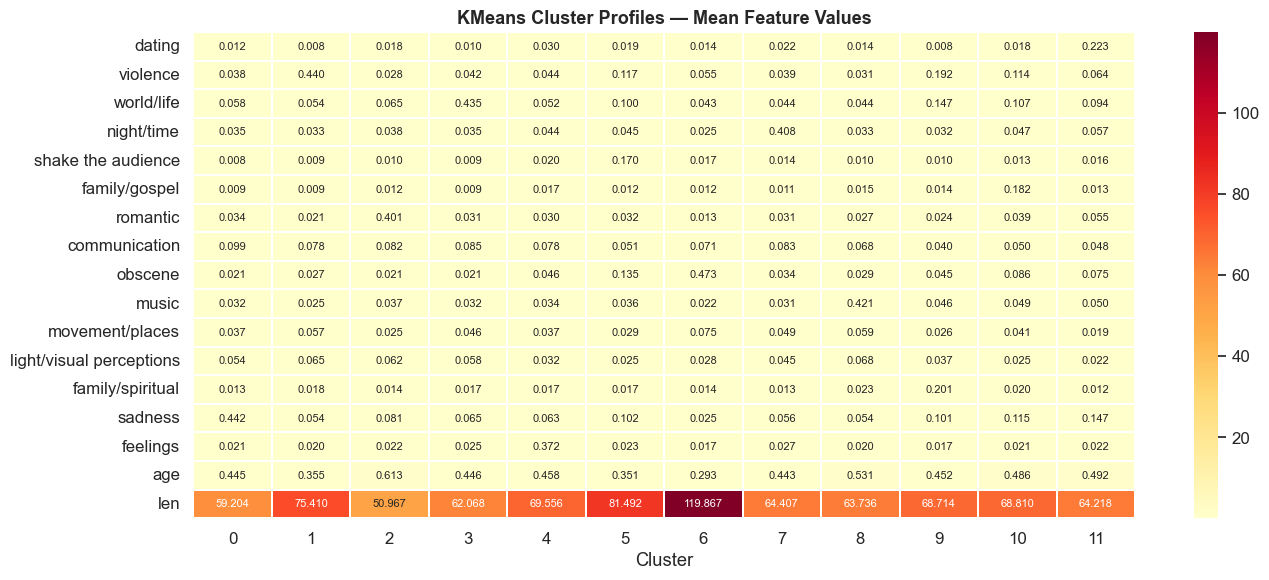

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, annot_kws={'size': 8})
ax.set_title('KMeans Cluster Profiles — Mean Feature Values', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig19_cluster_heatmap.png', bbox_inches='tight')


- The heatmap reveals clearly distinct cluster identities, no two clusters share the same dominant feature pattern. Cluster 6 stands out immediately with the highest `obscene` score and the longest average lyrics (`len`), confirming it as the explicit hip hop cluster. Clusters 0 and 11 are dominated by `sadness`, while Clusters 2 and 11 show elevated `romantic` and `dating` scores respectively. Clusters 9 and 10 show elevated `family/spiritual` and `family/gospel` scores, capturing the faith-based song groups. The heatmap validates that KMeans has successfully carved the feature space into thematically coherent groups rather than arbitrary geometric partitions.


In [11]:
print("Genre distribution per cluster:")
print(train_orig.groupby('cluster')['genre'].value_counts().unstack(fill_value=0))
print("\nTopic distribution per cluster:")
print(train_orig.groupby('cluster')['topic'].value_counts().unstack(fill_value=0))

Genre distribution per cluster:
genre    blues  country  hip hop  jazz   pop  reggae  rock
cluster                                                   
0          663     1326       31   576  1339     207   717
1          820      530       83   554  1019     450  1107
2          293      343        3   322   453      46   141
3          550     1011       37   635  1131     425   633
4          189      142        4    98   187      65   107
5          178      104       36   121   325     125   198
6          405      485      651   570   988     577   302
7          324      346        9   194   437     126   258
8          398      536       14   359   455     116   182
9          194      189       15   184   241     212   205
10         262      267       11   109   188      83    99
11         327      165       10   122   275      65    83

Topic distribution per cluster:
topic    feelings  music  night/time  obscene  romantic  sadness  violence  \
cluster                        

- The genre and topic distributions per cluster confirm the thematic coherence seen in the heatmap. Most clusters have a single dominant topic that accounts for the majority of songs, for example, Cluster 2 is predominantly `romantic` topic, Cluster 6 is predominantly `obscene`, and Cluster 8 is dominated by `music` topic. The genre distributions are less clean (pop dominates many clusters due to dataset imbalance) but still informative, Cluster 1 skews heavily toward rock, Cluster 4 and 11 toward blues, and Cluster 8 toward country. The alignment between cluster labels, feature profiles, and topic/genre distributions confirms that the unsupervised model has recovered structure that matches real-world musical categories.

---
#### 6.2 Cluster profile Radar charts

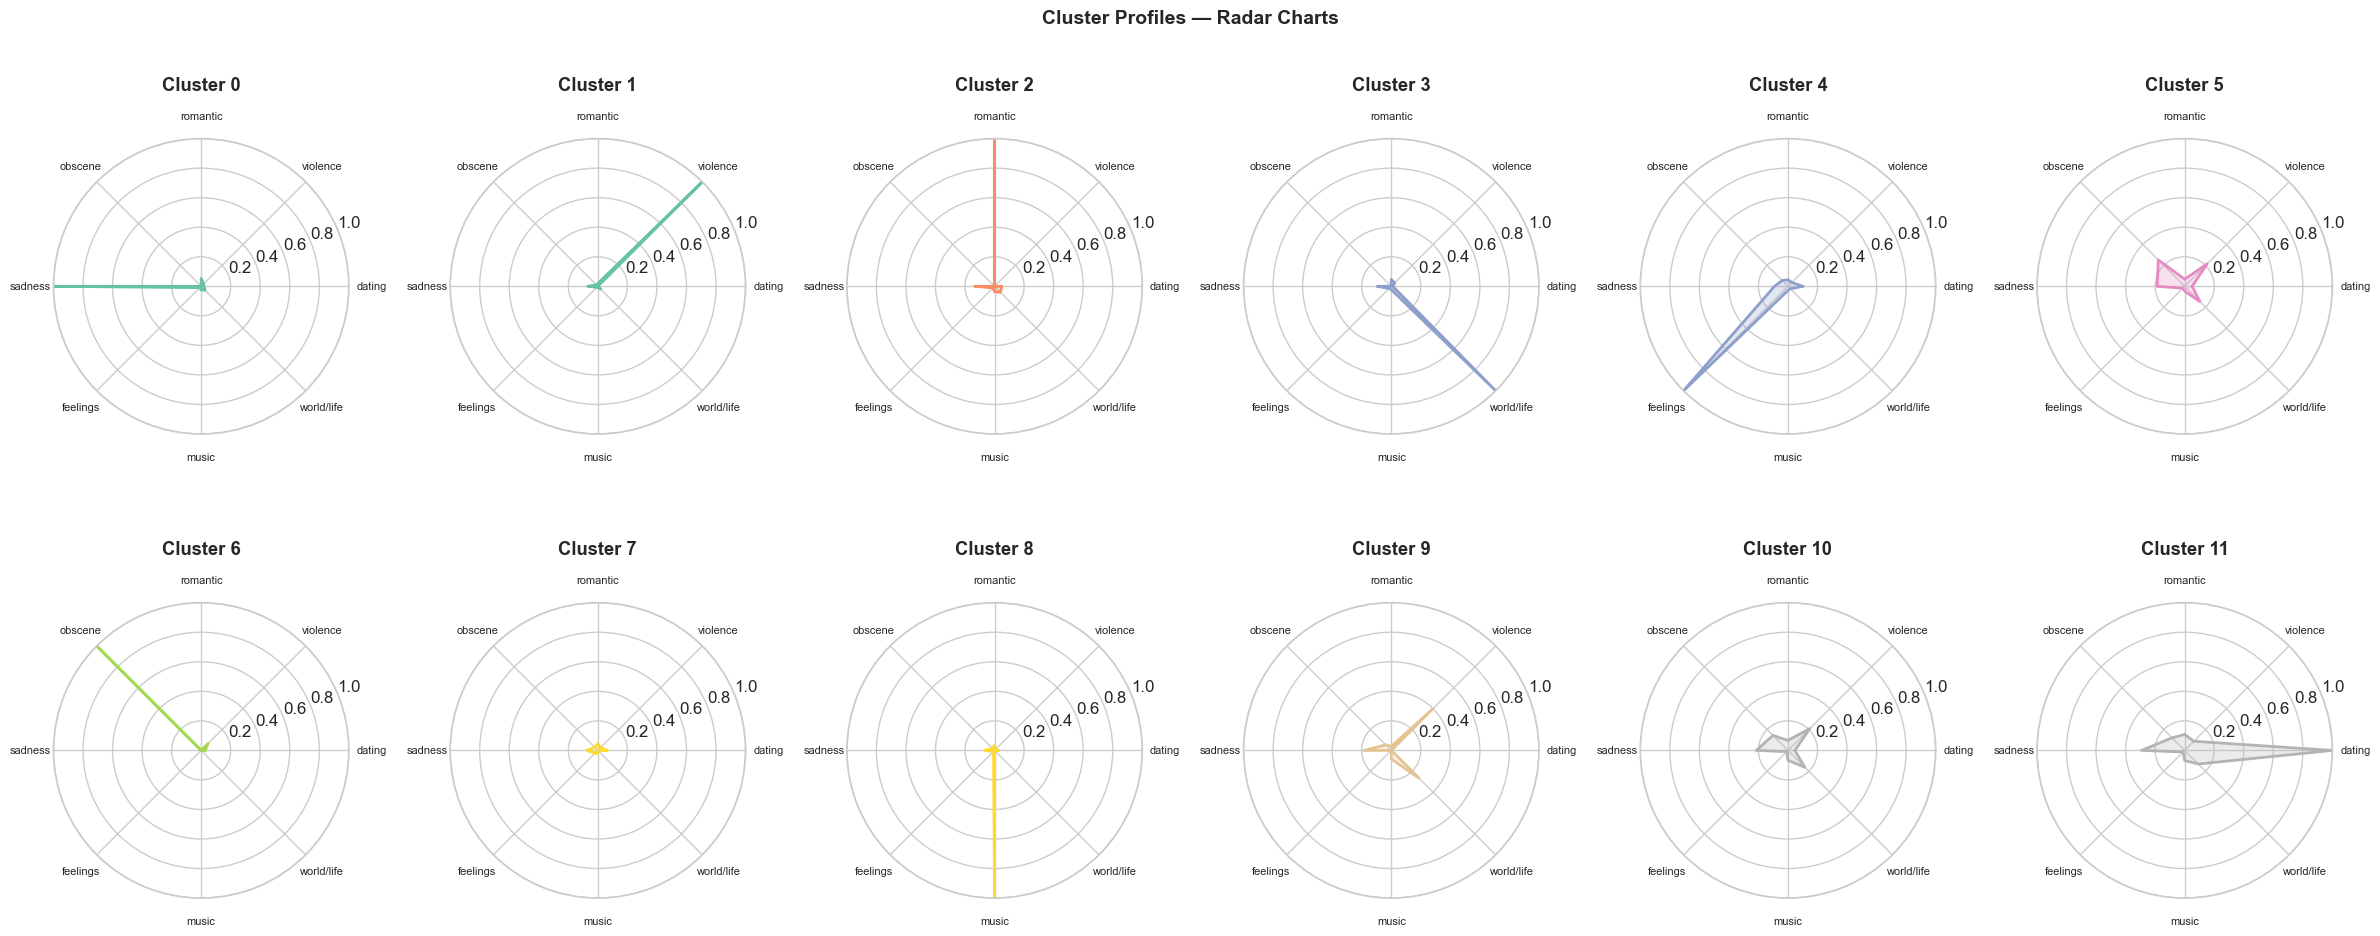

In [12]:
features_radar = ['dating','violence','romantic','obscene','sadness','feelings','music','world/life']
means_radar = train_orig.groupby('cluster')[features_radar].mean()
means_norm = (means_radar - means_radar.min()) / (means_radar.max() - means_radar.min() + 1e-9)

angles = np.linspace(0, 2*np.pi, len(features_radar), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 6, figsize=(24, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()
colors = plt.cm.Set2(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    vals = means_norm.iloc[i].tolist() + [means_norm.iloc[i].tolist()[0]]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_thetagrids(np.degrees(angles[:-1]), features_radar, fontsize=8)
    axes[i].set_title(f'Cluster {i}', fontweight='bold', pad=15)
    axes[i].set_ylim(0, 1)

plt.suptitle('Cluster Profiles — Radar Charts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig20_cluster_radar.png', bbox_inches='tight')


- The radar charts give an intuitive visual fingerprint of each cluster's personality. Clusters with a single large spike (like Cluster 6 spiking on `obscene`, or Cluster 2 spiking on `romantic`) are the most "pure" and well-defined. Clusters with broader, more distributed shapes (like Cluster 3 and 4) represent songs that blend multiple themes, these are the softer, less cleanly separated groups. The variety in radar shapes confirms that k=12 is capturing genuinely different archetypes rather than subtle variations of the same profile.

---
### 7. Visualize Clusters in 2D PCA Space

- By reducing the 14-dimensional PCA space further down to 2 dimensions purely for visualization, this is not used in the model itself. Plotting the clusters in 2D visually verify whether the groups are spatially coherent or randomly scattered.

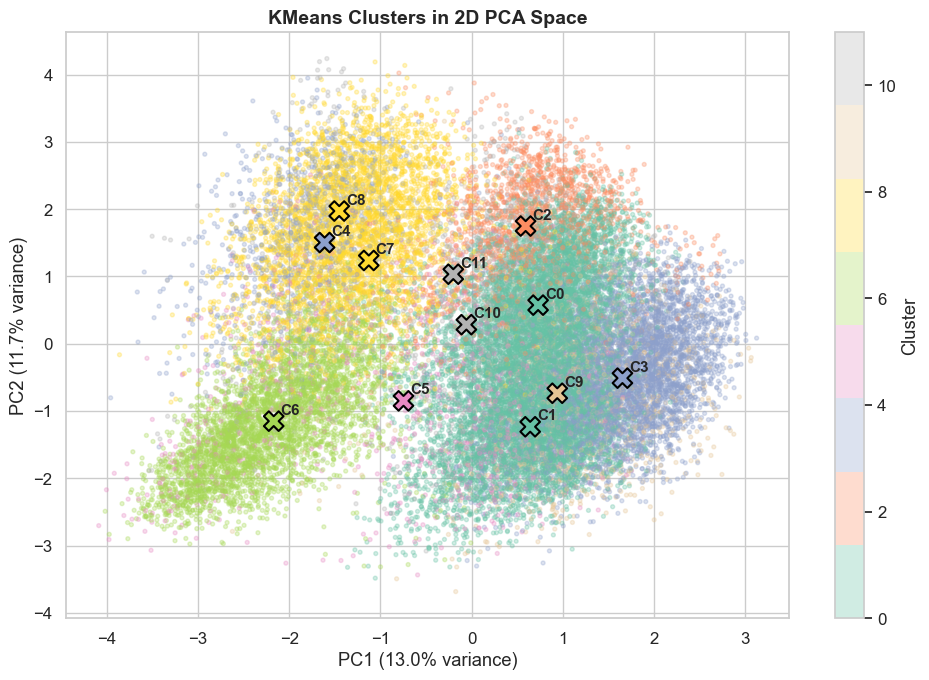

In [13]:
from sklearn.decomposition import PCA as PCA2D

pca2d = PCA2D(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(df.values)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels,
                     cmap='Set2', alpha=0.3, s=8)
centroids_2d = pca2d.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c=range(BEST_K), cmap='Set2', s=200, marker='X',
           edgecolors='black', linewidths=1.5, zorder=5, label='Centroids')
for i, (cx, cy) in enumerate(centroids_2d):
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')
ax.set_title('KMeans Clusters in 2D PCA Space', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig21_cluster_scatter.png', bbox_inches='tight')

- Here, the 2D scatter shows that clusters are not perfectly separated spheres, there is visible overlap between several groups, particularly in the dense center of the plot. This is expected for two reasons: first, compressing 14 dimensions into 2 always causes some spatial distortion and overlap that doesn't exist in the full 14D space; second, music themes genuinely blend and co-exist, so soft boundaries are the realistic expectation. The clusters that do show clear spatial separation in 2D (particularly Cluster 6, the explicit hip hop cluster, which tends to sit away from the emotional clusters) are the most distinct and well-defined groups in the dataset. The X markers show that centroid positions are spread across the 2D space, confirming the model isn't collapsing all clusters to the same region.

---
### 8. Save clustered training data

In [14]:
train_orig.to_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/train_clustered.csv', index=False)
print("Saved data_clustered.csv:", train_orig.shape)
print("\nCluster counts:")
print(train_orig['cluster'].value_counts().sort_index())

Saved data_clustered.csv: (28362, 25)

Cluster counts:
cluster
0     4859
1     4563
2     1601
3     4422
4      792
5     1087
6     3978
7     1694
8     2060
9     1240
10    1019
11    1047
Name: count, dtype: int64


---
### 9. Apply to Test Dataset (recommend.csv)

In [ ]:
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/pca.pkl', 'rb') as f:
    pca = pickle.load(f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/le_genre.pkl', 'rb') as f:
    le_genre = pickle.load(f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/le_topic.pkl', 'rb') as f:
    le_topic = pickle.load(f)

test = pd.read_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/recommend.csv')
test_orig = test.copy()
print("Test dataset shape:", test.shape)
test_orig[['artist_name', 'track_name', 'genre', 'topic']].head(10)

Test dataset shape: (10, 25)


,artist_name,track_name,genre,topic
0,godsmack,immune,rock,world/life
1,dennis brown,second chance,reggae,night/time
2,the black crowes,sister luck,pop,violence
3,jerry lee lewis,your cheating heart,pop,sadness
4,paul anka,eso beso,pop,romantic
5,noro morales,silencio,jazz,violence
6,rage against the machine,pistol grip pump,rock,obscene
7,taste,railway and gun,blues,sadness
8,randy travis,messin' with my mind,country,night/time
9,paramore,playing god,pop,violence


The test dataset (`recommend.csv`) contains 10 songs we want to recommend to a user. To assign each song to a cluster, I must:
1. Apply the **exact same preprocessing** as the training data (same scaler, same PCA, same encoders)
2. Use the **fitted KMeans model** to predict which cluster each test song belongs to

This tells me which "type" of song each recommendation is, and by comparing that to the user's cluster preferences, I can determine which songs are most aligned with their taste.

---
### 10. Dropping columns

In [16]:
drop_cols = [c for c in ['lyrics','artist_name','track_name','release_date','Unnamed: 0'] if c in test.columns]
test = test.drop(columns=drop_cols)
print("After dropping columns:", test.shape)

After dropping columns: (10, 20)


- Same columns dropped as in training, lyrics, identifiers, and the unnamed index. The if c in test.columns check is a safety guard in case the test CSV is missing any of those columns, so it doesn't crash.

---
### 11. Handle unseen categories

In [17]:
for col, le in [('genre', le_genre), ('topic', le_topic)]:
    test[col] = test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
print("Categories validated.")

Categories validated.


- Before encoding, I need to check if the test set contains any genre or topic values that never appeared in the training data. If the LabelEncoder encounters an unknown label it will crash, so any unseen value is replaced with the first known class as a safe fallback.

---
### 12. Encode `genre` and `topic`

In [18]:
test['genre_enc'] = le_genre.transform(test['genre'])
test['topic_enc'] = le_topic.transform(test['topic'])
test = test.drop(columns=['genre', 'topic'])
print("After encoding:", test.shape)

After encoding: (10, 20)


- Applying the same LabelEncoder fitted on the training data to convert `genre` and `topic` into integers. Using the same encoder is critical, it ensures "pop" maps to the same integer in both the training and test datasets. The original text columns are then dropped 
since they have been replaced by their encoded versions.

---
### 13. Align columns to match training

In [19]:
extra = set(test.columns) - set(feature_cols)
if extra:
    print("Dropping extra columns:", extra)
    test = test.drop(columns=list(extra))
test = test[feature_cols]
print("Columns aligned:", test.shape)

Dropping extra columns: {'like/girls'}
Columns aligned: (10, 19)


- The recommend CSV contains a `like/girls` column that does not exist in the training dataset. Any extra columns are dropped here, and the remaining columns are reordered to exactly match the training feature order. This step is important because both the scaler and PCA are strict about column order, a mismatch would produce wrong results without throwing an error.

---
### 14. Scale the data

In [20]:
X_test_scaled = scaler.transform(test)
print("Scaled shape:", X_test_scaled.shape)

Scaled shape: (10, 19)


- Applying the StandardScaler that was fitted on the training data. Notice this uses `.transform()` not `.fit_transform()`, I am applying the mean and standard deviation values learned from training, not recalculating new ones from the test data. Refitting 
on the test set would put it on a different scale than the training data, making the cluster predictions meaningless.

---
### 15. Apply PCA

In [21]:
X_test_pca = pca.transform(X_test_scaled)
print("PCA shape:", X_test_pca.shape)

PCA shape: (10, 14)


- Applying the same PCA transformation fitted on training data to project the test songs into the same 14-dimensional space. Again, `.transform()` is used, not `.fit_transform()`. This ensures the test songs land on the same axes as the training songs so that KMeans 
distance calculations are comparing apples to apples.

---
### 16. Predict Clusters

In [22]:
test_clusters = kmeans_final.predict(X_test_pca)
test_orig['cluster'] = test_clusters
print("Cluster assignments:")
print(test_orig[['artist_name', 'track_name', 'genre', 'topic', 'cluster']].to_string(index=False))

Cluster assignments:
             artist_name           track_name   genre      topic  cluster
                godsmack               immune    rock world/life        5
            dennis brown        second chance  reggae night/time        7
        the black crowes          sister luck     pop   violence       10
         jerry lee lewis  your cheating heart     pop    sadness       11
               paul anka             eso beso     pop   romantic        2
            noro morales             silencio    jazz   violence        1
rage against the machine     pistol grip pump    rock    obscene        6
                   taste      railway and gun   blues    sadness        0
            randy travis messin' with my mind country night/time        7
                paramore          playing god     pop   violence        1


- The 10 test songs were distributed across 8 different clusters, confirming this is a diverse listener with broad musical taste rather than someone locked into a single genre or theme. Two clusters received 2 songs each (Cluster 1 — Hard Rock/Metal, and Cluster 7 — Night & Party), suggesting these are the user's strongest preference areas. The fact that songs like Rage Against the Machine landed in Cluster 6 (Explicit Hip Hop) and Jerry Lee Lewis landed in Cluster 11 (Blues Heartache) shows the model is correctly identifying thematic similarity across genre boundaries, which is exactly what a good recommendation system should do.

---
### 17. Test Set Cluster Assignments

In [23]:
print("Sample songs per cluster from test set:")
for c in sorted(test_orig['cluster'].unique()):
    subset = test_orig[test_orig['cluster'] == c][['artist_name','track_name','genre','topic']]
    print(f"\nCluster {c}:")
    print(subset.to_string(index=False))

Sample songs per cluster from test set:

Cluster 0:
artist_name      track_name genre   topic
      taste railway and gun blues sadness

Cluster 1:
 artist_name  track_name genre    topic
noro morales    silencio  jazz violence
    paramore playing god   pop violence

Cluster 2:
artist_name track_name genre    topic
  paul anka   eso beso   pop romantic

Cluster 5:
artist_name track_name genre      topic
   godsmack     immune  rock world/life

Cluster 6:
             artist_name       track_name genre   topic
rage against the machine pistol grip pump  rock obscene

Cluster 7:
 artist_name           track_name   genre      topic
dennis brown        second chance  reggae night/time
randy travis messin' with my mind country night/time

Cluster 10:
     artist_name  track_name genre    topic
the black crowes sister luck   pop violence

Cluster 11:
    artist_name          track_name genre   topic
jerry lee lewis your cheating heart   pop sadness


In [23]:
test_orig.to_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/recommend_clustered.csv', index=False)
print("Saved test_clustered.csv:", test_orig.shape)

Saved test_clustered.csv: (10, 26)


---
### Conclusion

- The KMeans model successfully recovered thematically coherent song groupings purely from numeric lyric theme scores, without ever being told what genre or topic a song belongs to. All three hypotheses from the EDA were confirmed, the bipolar dark/explicit vs emotional/spiritual structure emerged clearly in the cluster profiles, hip hop formed the most compact and well-separated cluster, and topic labels proved to be a more reliable validator of cluster quality than genre labels. The 10 test songs were distributed across 8 different clusters, revealing a diverse listener whose taste spans rock, blues, romantic, gospel, and explicit content. This cluster assignment is the foundation for the recommendation logic, songs from the user's most represented clusters in the test set are the strongest candidates to recommend back to them from the full training dataset.